# Anchor-aware coefficient audit

This artifact-only notebook decomposes the apparent upward EDR recommendation into effective-information feedback, population movement, realized anchor displacement, and online trend energy. It does not train a model or redefine an optimal policy.

In [1]:
from pathlib import Path
import sys

repo_root = next(
    candidate
    for candidate in (Path.cwd(), *Path.cwd().parents)
    if (candidate / 'mnist_experiment' / 'plan7.md').is_file()
)
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

from mnist_experiment.rotated_mnist.phase7_artifacts import load_completed_phase7_audit

artifact_path = (
    repo_root / 'cache' / 'mnist_experiment' / 'rotated_mnist' / 'phase7'
    / 'coefficient_audit'
    / 'rotated_mnist_phase7_anchor_audit_primary_v3__replica-0001__4406a8e7634c0ad8'
)
audit = load_completed_phase7_audit(artifact_path)
rows = pd.DataFrame(audit.coefficient_rows)
summaries = pd.DataFrame(audit.audit_summary['summaries'])
primary = rows[(rows['condition'] == audit.config.primary_condition) & (rows['rank'] == audit.config.primary_rank)].copy()
print(f'Audit: {audit.config.run_id}')
print(f'Rows: {len(rows)}; classification: {audit.audit_summary["evidence_classification"]["classification"]}')

Audit: rotated_mnist_phase7_anchor_audit_primary_v3__replica-0001__4406a8e7634c0ad8
Rows: 960; classification: mixed_reference_offset_and_online_signal_inflation


## Targets and conditioning

If historical observations have normalized weights $w_{t,i}$, define

$$q_t:=\sum_i w_{t,i}^2, \qquad N_{\mathrm{eff},t}:=q_t^{-1}.$$

An update retaining old weight $1-\pi_t$ and distributing new weight $\pi_t$ over $m_t$ observations gives

$$q_{t+1}=(1-\pi_t)^2q_t+\frac{\pi_t^2}{m_t}.$$

The centered marginal oracle uses $A_t^{\mathrm{marg}}=\|d\theta_t^\star\|_{\mathcal I_t}^2+q_tD_t$. The realized-anchor oracle instead conditions on $e_t=\widehat\theta_t-\theta_t^\star$ and uses

$$A_t^{\mathrm{cond}}=\|d\theta_t^\star-e_t\|_{\mathcal I_t}^2,$$

without adding $q_tD_t$. The online quadratic $\widehat d_t^TG_t\widehat d_t$ is an estimator whose intended target is precisely the question under audit.

In [2]:
columns = [
    'schedule', 'mean_applied_pi', 'mean_covariance_only_pi',
    'mean_centered_marginal_pi', 'mean_online_plugin_pi',
    'mean_debiased_online_pi', 'mean_realized_conditional_pi',
    'mean_efficient_mle_conditional_pi',
]
labels = {
    'mean_applied_pi': 'Applied EDR',
    'mean_covariance_only_pi': 'Covariance only',
    'mean_centered_marginal_pi': 'Centered marginal',
    'mean_online_plugin_pi': 'Online plug-in',
    'mean_debiased_online_pi': 'Debiased online',
    'mean_realized_conditional_pi': 'Conditional, measured $K$',
    'mean_efficient_mle_conditional_pi': 'Conditional, $D=p$ sensitivity',
}
primary_summary = summaries[(summaries['condition'] == audit.config.primary_condition) & (summaries['rank'] == audit.config.primary_rank)][columns].rename(columns=labels)
display(primary_summary.style.format({name: '{:.3f}' for name in labels.values()}))

,schedule,Applied EDR,Covariance only,Centered marginal,Online plug-in,Debiased online,"Conditional, measured $K$","Conditional, $D=p$ sensitivity"
1,linear,0.277,0.135,0.137,0.262,0.244,0.926,0.495
7,sigmoid,0.300,0.143,0.146,0.298,0.274,0.890,0.318


## Effective-information feedback

### The population estimand

In a locally stationary environment, let $e_t=\widehat\theta_t-\theta^\star$ denote old-summary error and let $\epsilon_{t+1}=\widetilde\theta_{t+1}-\theta^\star$ denote an independent fresh-batch error. Assume

$$\operatorname{Cov}(e_t\mid\mathcal E_t)=q_tK_t, \qquad \operatorname{Cov}(\epsilon_{t+1}\mid\mathcal E_t)=\frac{K_{t+1}}{m_t}.$$

For $\widehat\theta_{t+1}(\pi)\approx(1-\pi)\widehat\theta_t+\pi\widetilde\theta_{t+1}$, the **true covariance-only recommendation** is the population quantity

$$\pi_t^{\mathrm{cov}}:=\underset{\pi\in[0,1]}{\arg\min}\;\mathbb E\!\left[\left\|\widehat\theta_{t+1}(\pi)-\theta^\star\right\|_{\mathcal I_t}^2\,\middle|\,\mathcal E_t\right].$$

Writing $D_t^{\mathrm{old}}=\operatorname{tr}(\mathcal I_tK_t)$ and $D_t^{\mathrm{new}}=\operatorname{tr}(\mathcal I_tK_{t+1})$, its risk and exact minimizer are

$$R_t^{\mathrm{cov}}(\pi)=(1-\pi)^2q_tD_t^{\mathrm{old}}+\pi^2\frac{D_t^{\mathrm{new}}}{m_t},$$

$$\pi_t^{\mathrm{cov}}=\frac{q_tD_t^{\mathrm{old}}}{q_tD_t^{\mathrm{old}}+D_t^{\mathrm{new}}/m_t}.$$

This is an estimand of the stipulated probability law, not the post-facto best action on an observed accuracy trajectory. It is marginal over repeated learner histories conditional on $\mathcal E_t$; conditioning on the realized learner anchor produces the different conditional target studied below.

### A matrix-free recommendation and its stationary limit

When the local covariance shapes match, $D_t^{\mathrm{old}}\approx D_t^{\mathrm{new}}$, the unknown matrix terms cancel:

$$\widehat\pi_t^{\mathrm{cov},q}=\frac{m_tq_t}{1+m_tq_t}.$$

Here $q_t$ is tracked deterministically from the controller's known weight history, so this recommendation has no additional sampling noise. For a constant action $c$ and batch size $m$, $q_t$ converges to

$$q_\infty(c)=\frac{c}{m(2-c)},$$

which gives the stationary simplification

$$\widehat\pi_t^{\mathrm{cov},\mathrm{stat}}=\frac{c}{2}.$$

The line $c/2$ is therefore calculated from a known action rather than estimated from samples. Its uncertainty is structural: local stationarity, matching covariance shape, and covariance calibration may fail. The tracked-$q_t$ form is preferable when actions vary. Neither expression should be iterated as $c_{t+1}=c_t/2$; that recursion would mechanically converge to zero. With nonzero population movement $S_t=\|d\theta_t^\star\|_{\mathcal I_t}^2$, the centered marginal recommendation is at least as large as this covariance-only baseline.

,schedule,MAE: tracked $q_t$ vs. population oracle,MAE: stationary $c_t/2$ vs. population oracle,Movement lift over covariance only
0,linear,0.0008,0.0094,0.0026
1,sigmoid,0.0009,0.0120,0.0026


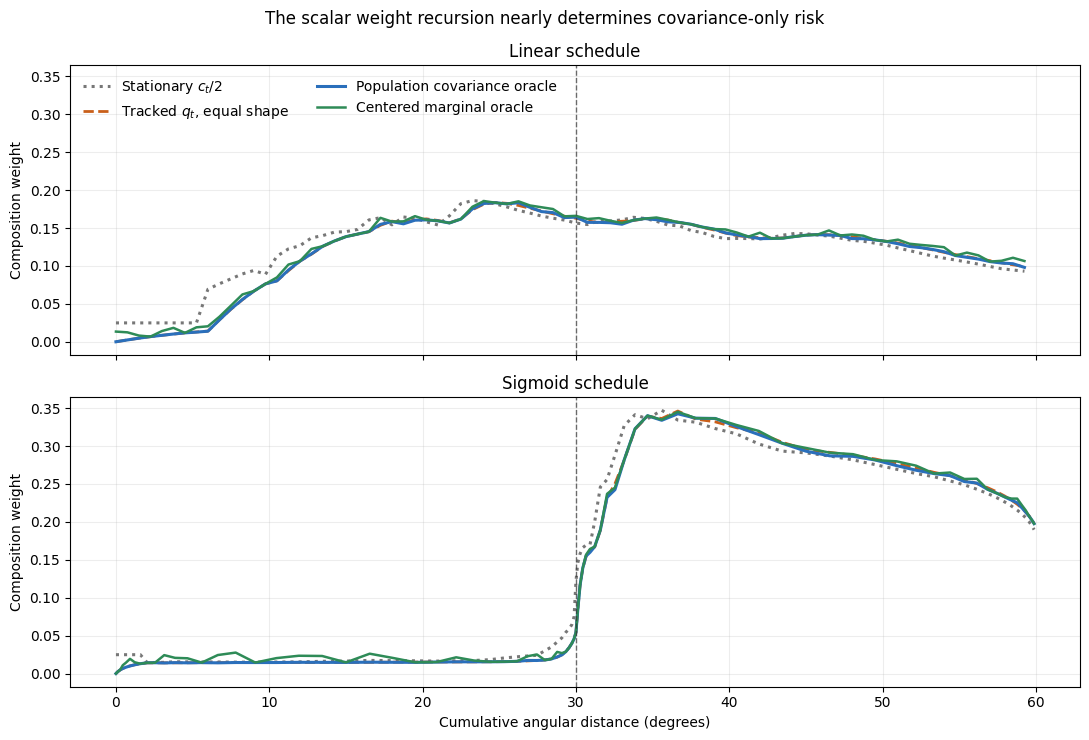

In [3]:
batch_size = audit.config.deployed_batch_size
primary['equal_shape_covariance_pi'] = (batch_size * primary['q']) / (1.0 + batch_size * primary['q'])
feedback_rows = []
for schedule in audit.config.schedule_kinds:
    data = primary[(primary['schedule'] == schedule) & ~primary['cold_start']]
    feedback_rows.append({
        'schedule': schedule,
        r'MAE: tracked $q_t$ vs. population oracle': np.mean(np.abs(data['equal_shape_covariance_pi'] - data['covariance_only_pi'])),
        r'MAE: stationary $c_t/2$ vs. population oracle': np.mean(np.abs(data['applied_pi'] / 2.0 - data['covariance_only_pi'])),
        'Movement lift over covariance only': np.mean(data['centered_marginal_pi'] - data['covariance_only_pi']),
    })
display(pd.DataFrame(feedback_rows).style.format({column: '{:.4f}' for column in feedback_rows[0] if column != 'schedule'}))

fig, axes = plt.subplots(2, 1, figsize=(11, 7.5), sharex=True, sharey=True)
for axis, schedule in zip(axes, audit.config.schedule_kinds, strict=True):
    data = primary[primary['schedule'] == schedule]
    x = data['cumulative_angular_degrees']
    axis.plot(x, data['applied_pi'] / 2, color='#777777', linestyle=':', linewidth=2.2, label=r'Stationary $c_t/2$')
    axis.plot(x, data['equal_shape_covariance_pi'], color='#c95f1a', linestyle='--', linewidth=2, label=r'Tracked $q_t$, equal shape')
    axis.plot(x, data['covariance_only_pi'], color='#2a6fbb', linewidth=2.2, label='Population covariance oracle')
    axis.plot(x, data['centered_marginal_pi'], color='#2e8b57', linewidth=1.8, label='Centered marginal oracle')
    axis.axvline(30, color='#333333', linestyle='--', linewidth=1, alpha=.7)
    axis.set_title(f'{schedule.capitalize()} schedule')
    axis.set_ylabel('Composition weight')
    axis.grid(alpha=.22)
axes[-1].set_xlabel('Cumulative angular distance (degrees)')
axes[0].legend(ncol=2, frameon=False, loc='upper left')
fig.suptitle('The scalar weight recursion nearly determines covariance-only risk')
fig.tight_layout()
plt.show()

## Marginal versus realized-anchor targets

The measured-$K$ conditional curve uses the covariance of six-epoch local Adam fits. Its Fisher-weighted covariance shape averages only about $15.8$, versus the regular efficient-MLE benchmark $D=p=512$. The $D=p$ curve is therefore a declared sensitivity, not an empirical oracle.

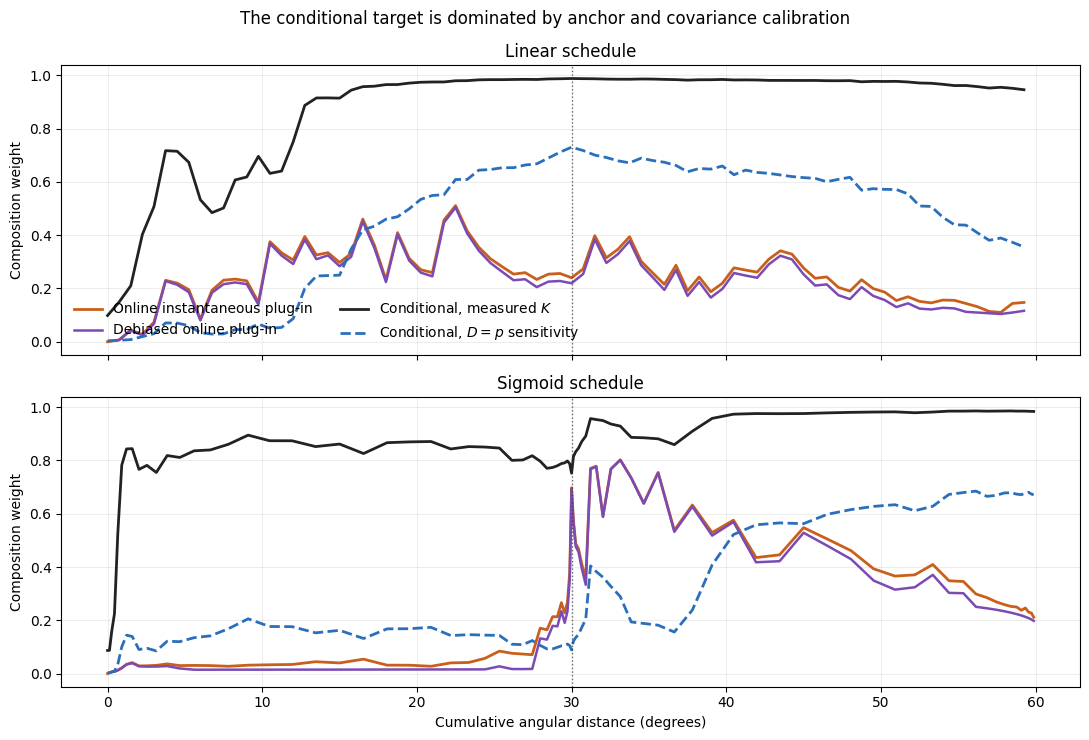

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7.5), sharex=True, sharey=True)
for axis, schedule in zip(axes, audit.config.schedule_kinds, strict=True):
    data = primary[primary['schedule'] == schedule]
    x = data['cumulative_angular_degrees']
    axis.plot(x, data['online_plugin_pi'], color='#c95f1a', linewidth=2, label='Online instantaneous plug-in')
    axis.plot(x, data['debiased_online_pi'], color='#7b4ab5', linewidth=1.8, label='Debiased online plug-in')
    axis.plot(x, data['realized_conditional_pi'], color='#222222', linewidth=2, label='Conditional, measured $K$')
    axis.plot(x, data['efficient_mle_conditional_pi'], color='#2a6fbb', linestyle='--', linewidth=2, label='Conditional, $D=p$ sensitivity')
    axis.axvline(30, color='#333333', linestyle=':', linewidth=1, alpha=.7)
    axis.set_title(f'{schedule.capitalize()} schedule')
    axis.set_ylabel('Composition weight')
    axis.grid(alpha=.22)
axes[-1].set_xlabel('Cumulative angular distance (degrees)')
axes[0].legend(ncol=2, frameon=False, loc='lower left')
fig.suptitle('The conditional target is dominated by anchor and covariance calibration')
fig.tight_layout()
plt.show()

## Anchor decomposition

For every transition the audit verifies

$$\|d\theta_t^\star-e_t\|_{\mathcal I_t}^2=(d\theta_t^\star)^T\mathcal I_td\theta_t^\star+e_t^T\mathcal I_te_t-2e_t^T\mathcal I_td\theta_t^\star.$$

The signed cross term is retained rather than folded invisibly into the conditional energy.

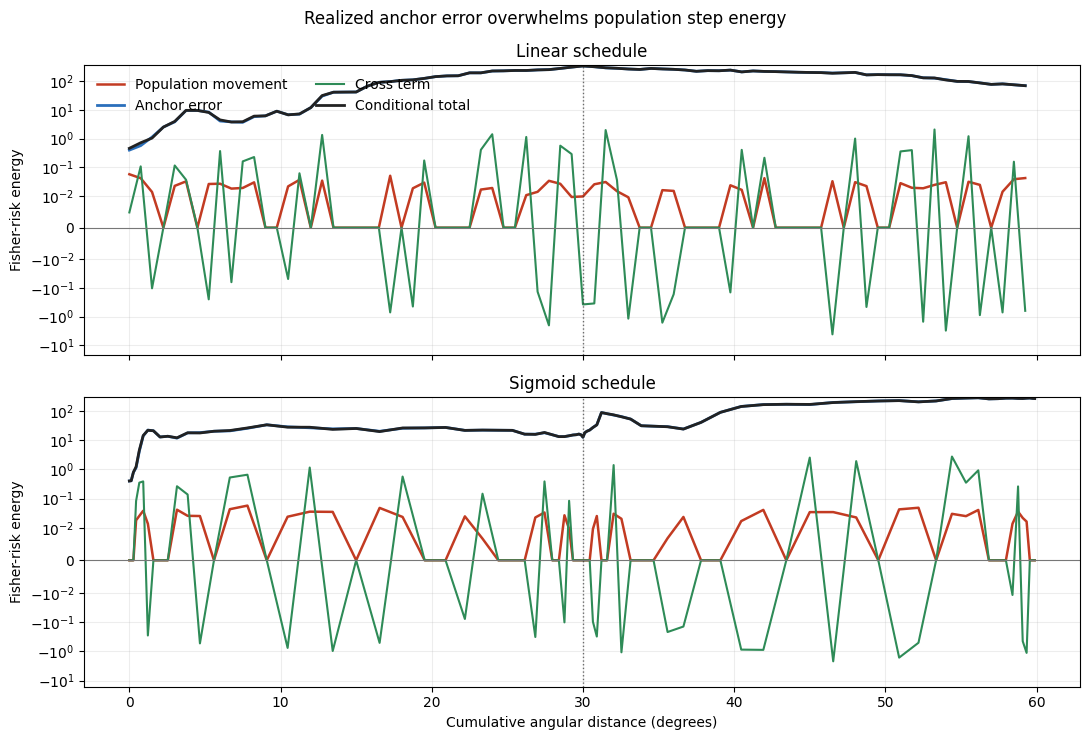

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7.5), sharex=True)
for axis, schedule in zip(axes, audit.config.schedule_kinds, strict=True):
    data = primary[primary['schedule'] == schedule]
    x = data['cumulative_angular_degrees']
    axis.plot(x, data['population_signal_raw'], color='#c23b22', linewidth=1.8, label='Population movement')
    axis.plot(x, data['anchor_error_energy'], color='#2a6fbb', linewidth=2, label='Anchor error')
    axis.plot(x, data['cross_term'], color='#2e8b57', linewidth=1.5, label='Cross term')
    axis.plot(x, data['conditional_signal_raw'], color='#222222', linewidth=2, label='Conditional total')
    axis.axhline(0, color='#777777', linewidth=.8)
    axis.axvline(30, color='#333333', linestyle=':', linewidth=1, alpha=.7)
    axis.set_yscale('symlog', linthresh=1e-2)
    axis.set_title(f'{schedule.capitalize()} schedule')
    axis.set_ylabel('Fisher-risk energy')
    axis.grid(alpha=.22)
axes[-1].set_xlabel('Cumulative angular distance (degrees)')
axes[0].legend(ncol=2, frameon=False, loc='upper left')
fig.suptitle('Realized anchor error overwhelms population step energy')
fig.tight_layout()
plt.show()

## Policy dependence of anchor error

All three policies share the same initializer and data streams. Their different anchor trajectories are descriptive matched evidence that the error is not merely the initial reference offset. They are not independent replicas.

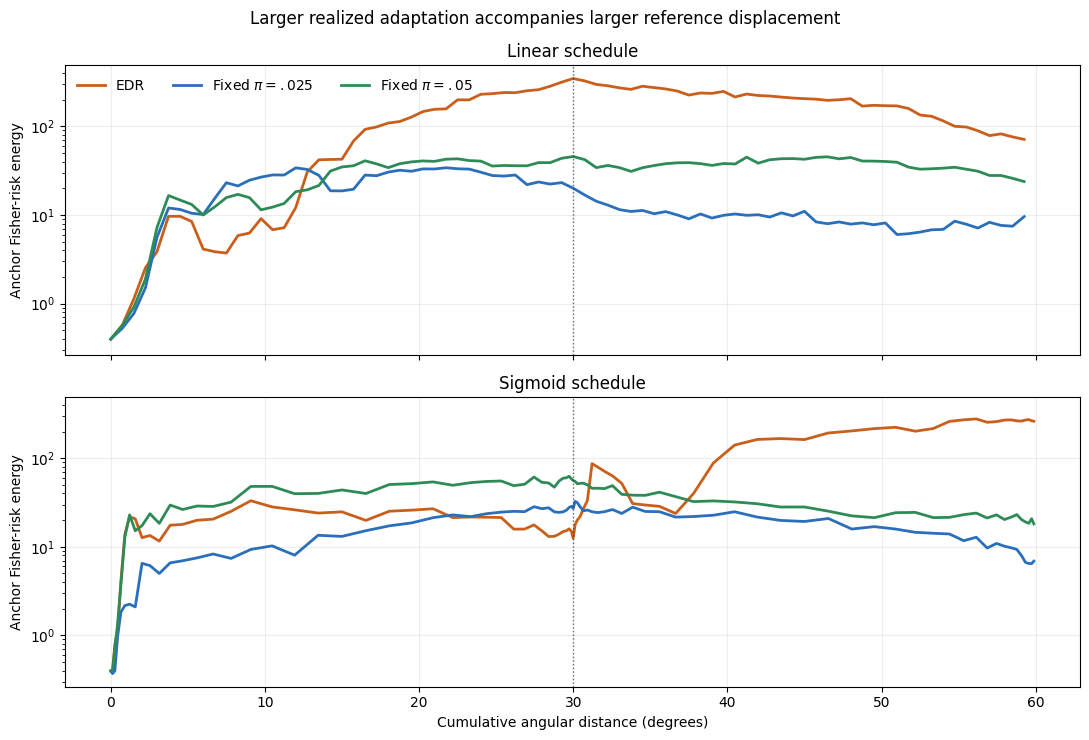

In [6]:
condition_labels = {
    'edr_slowtrend_slowaction': 'EDR',
    'fixed_pi0025': r'Fixed $\pi=.025$',
    'fixed_pi005': r'Fixed $\pi=.05$',
}
condition_colors = {'edr_slowtrend_slowaction': '#c95f1a', 'fixed_pi0025': '#2a6fbb', 'fixed_pi005': '#2e8b57'}
rank_rows = rows[rows['rank'] == audit.config.primary_rank]
fig, axes = plt.subplots(2, 1, figsize=(11, 7.5), sharex=True, sharey=True)
for axis, schedule in zip(axes, audit.config.schedule_kinds, strict=True):
    for condition in audit.config.conditions:
        data = rank_rows[(rank_rows['schedule'] == schedule) & (rank_rows['condition'] == condition)]
        axis.plot(data['cumulative_angular_degrees'], data['anchor_error_energy'], color=condition_colors[condition], linewidth=2, label=condition_labels[condition])
    axis.axvline(30, color='#333333', linestyle=':', linewidth=1, alpha=.7)
    axis.set_yscale('log')
    axis.set_title(f'{schedule.capitalize()} schedule')
    axis.set_ylabel('Anchor Fisher-risk energy')
    axis.grid(alpha=.22)
axes[-1].set_xlabel('Cumulative angular distance (degrees)')
axes[0].legend(ncol=3, frameon=False, loc='upper left')
fig.suptitle('Larger realized adaptation accompanies larger reference displacement')
fig.tight_layout()
plt.show()

In [7]:
shape_table = primary_summary[['schedule']].copy()
shape_source = summaries[(summaries['condition'] == audit.config.primary_condition) & (summaries['rank'] == audit.config.primary_rank)].reset_index(drop=True)
shape_table['Measured old $D_t$'] = shape_source['mean_old_covariance_shape_risk']
shape_table['Measured new $D_{t+1}$'] = shape_source['mean_new_covariance_shape_risk']
shape_table['Regular benchmark $p$'] = audit.branch_diagnostics['parameter_count']
shape_table['Measured / $p$'] = shape_source['mean_old_shape_fraction_of_parameter_count']
display(shape_table.style.format({'Measured old $D_t$': '{:.2f}', 'Measured new $D_{t+1}$': '{:.2f}', 'Measured / $p$': '{:.3%}'}))

,schedule,Measured old $D_t$,Measured new $D_{t+1}$,Regular benchmark $p$,Measured / $p$
1,linear,15.83,15.86,512,3.092%
7,sigmoid,nan,nan,512,nan%


## Findings

1. **Covariance-only risk has a rigorous low-noise estimator.** The tracked-$q_t$, equal-shape recommendation is a population-risk minimizer under the stated calibration model. Its mean absolute discrepancy from the stored population covariance oracle is only about $.0008$ on linear and $.0009$ on sigmoid.
2. **The factor of two is its stationary limit, not missing calculus.** The simpler $c_t/2$ reference has mean absolute discrepancies of about $.009$ and $.012$. It is useful when the action changes slowly, while the exact scalar $q_t$ recursion costs essentially nothing and handles nonstationarity better.
3. **This does not yet estimate the complete optimal action.** Population movement raises the centered marginal recommendation above the covariance-only baseline, although its mean lift here is only about $.0026$.
4. **Realized anchor error is large and policy-dependent.** Its live mean is much larger for EDR than for either fixed policy, despite a common initializer.
5. **The raw conditional oracle is not calibrated well enough to become a controller target.** Its local-fit covariance shape is about $3.1\%$ of the regular efficient benchmark. The $D=p$ sensitivity materially changes the answer.
6. **Current debiasing addresses too narrow a problem.** It removes quadratic trend variance but cannot remove systematic anchor divergence, serial optimizer dynamics, or covariance-shape error.

The evidence classification remains **mixed** for the complete controller, but the covariance-only subproblem is much cleaner than the original audit suggested. The combination of a population MSE derivation and near-exact artifact reproduction supports carrying the tracked-$q_t$ recommendation forward as a serious estimation paradigm. It does not by itself decide how movement or realized anchor error should enter the deployed action. Independent learner trajectories and a better-calibrated local covariance estimator are still needed to estimate $\mu_t$ and resolve that larger question.